# Metro Operations & Passenger Demand Analytics

## Project Overview

This project analyzes hourly passenger ridership across Bengaluru Metro
stations to identify passenger demand patterns, peak travel periods,
high-demand stations, and operational trends.

The analysis uses Python and Pandas for data preparation and exploratory
data analysis, followed by SQL-based business analysis and an interactive
Power BI dashboard.

## Business Problem

Metro operators need to understand when and where passenger demand is
highest in order to make informed decisions about train frequency,
capacity planning, and passenger-flow management.

This project uses historical station-level hourly ridership data to
identify passenger demand patterns and translate them into actionable
operational insights.

## Project Objectives

- Identify stations with the highest passenger demand.
- Determine peak passenger hours.
- Analyze daily ridership patterns.
- Compare weekday and weekend passenger demand.
- Identify high-demand periods that may require additional operational capacity.
- Generate actionable recommendations based on the analysis.

## Tools & Technologies

- **Python** — Data analysis and preprocessing
- **Pandas** — Data manipulation and cleaning
- **Matplotlib** — Data visualization
- **Seaborn** — Exploratory data visualization
- **SQL** — Business-oriented data analysis
- **Power BI** — Interactive dashboard and reporting

## Dataset

The primary dataset contains hourly passenger ridership records for
Bengaluru Metro stations.

### Key Variables

| Column | Description |
|---|---|
| Date | Date of the ridership observation |
| Hour | Hour of the day (0–23) |
| Station | Metro station |
| Ridership | Number of passengers recorded |

The dataset contains station-level hourly observations collected during
August 2025.

# 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd

In [2]:
file_path = r"E:\Metro-Operations-Analytics\data\station-hourly.csv"

df = pd.read_csv(file_path, sep=";")

The dataset is loaded into a Pandas DataFrame and the first five records are displayed to verify that the data has been loaded correctly.

In [3]:
df.head()

,Date,Hour,Station,Ridership
0,2025-08-01,0,Attiguppe,0
1,2025-08-01,1,Attiguppe,0
2,2025-08-01,2,Attiguppe,0
3,2025-08-01,3,Attiguppe,0
4,2025-08-01,4,Attiguppe,6


### Dataset Size

We first examine the number of records and columns in the dataset to understand its overall size.

In [4]:
# Display the number of rows and columns in the dataset.
df.shape

(92280, 4)

### Dataset Columns

We inspect the column names to understand the variables available for analysis.

In [5]:
df.columns


Index(['Date', 'Hour', 'Station', 'Ridership'], dtype='object')

### Data Types

We inspect the data type of each column to ensure that every variable is stored in an appropriate format for analysis.

In [6]:
# Display the data type of each column.
df.dtypes

Date         object
Hour          int64
Station      object
Ridership     int64
dtype: object

### Missing Values

We check each column for missing values to determine whether any records require additional cleaning or treatment.

In [7]:
# Count the number of missing values in each column.
df.isnull().sum()

Date         0
Hour         0
Station      0
Ridership    0
dtype: int64

### Duplicate Records

We check for duplicate rows to ensure that the same station-hour observation has not been recorded more than once.

In [8]:
# Count the number of completely duplicated rows.
df.duplicated().sum()

np.int64(0)

### Hour Validation

We verify that the `Hour` column contains valid hourly values ranging from 0 to 23.

In [9]:
# Display all unique hour values in sorted order.
sorted(df["Hour"].unique())

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23)]

### Ridership Validation

We verify that passenger ridership values are non-negative, since passenger counts cannot be negative.

In [10]:
# Check whether any ridership values are negative.
(df["Ridership"] < 0).sum()

np.int64(0)

### Date Range

We examine the earliest and latest dates in the dataset to understand the period covered by the ridership data.

In [11]:
# Display the earliest and latest dates in the dataset.
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2025-08-01
End date: 2025-09-30


### Date Coverage

We check the number of unique dates available to confirm the time period represented in the dataset.

In [12]:
# Count the number of unique dates in the dataset.
df["Date"].nunique()

48

### Date Completeness

Although the dataset spans August and September 2025, it contains fewer dates than the full calendar period. We identify the dates present in the dataset before deciding whether any dates are missing.

In [13]:
# Display all unique dates in chronological order.
sorted(df["Date"].unique())

['2025-08-01',
 '2025-08-02',
 '2025-08-03',
 '2025-08-04',
 '2025-08-05',
 '2025-08-06',
 '2025-08-07',
 '2025-08-08',
 '2025-08-09',
 '2025-08-10',
 '2025-08-11',
 '2025-08-12',
 '2025-08-13',
 '2025-08-14',
 '2025-08-15',
 '2025-08-16',
 '2025-08-17',
 '2025-08-18',
 '2025-09-01',
 '2025-09-02',
 '2025-09-03',
 '2025-09-04',
 '2025-09-05',
 '2025-09-06',
 '2025-09-07',
 '2025-09-08',
 '2025-09-09',
 '2025-09-10',
 '2025-09-11',
 '2025-09-12',
 '2025-09-13',
 '2025-09-14',
 '2025-09-15',
 '2025-09-16',
 '2025-09-17',
 '2025-09-18',
 '2025-09-19',
 '2025-09-20',
 '2025-09-21',
 '2025-09-22',
 '2025-09-23',
 '2025-09-24',
 '2025-09-25',
 '2025-09-26',
 '2025-09-27',
 '2025-09-28',
 '2025-09-29',
 '2025-09-30']

### Hourly Record Coverage

We verify whether each station has a complete set of hourly observations for each date in the dataset.

In [14]:
# Calculate the number of unique dates, stations, and hours.
dates = df["Date"].nunique()
stations = df["Station"].nunique()
hours = df["Hour"].nunique()

# Calculate the expected number of records if every
# station has one observation for every hour of every date.
expected_records = dates * stations * hours

print("Expected records:", expected_records)
print("Actual records:", len(df))

Expected records: 95616
Actual records: 92280


### Station-Date Coverage

We check whether each station has a complete set of 24 hourly observations for every available date. This helps identify gaps in station-level coverage before performing further analysis.

In [15]:
# Count the number of hourly records for each station on each date.
station_date_counts = (
    df.groupby(["Date", "Station"])["Hour"]
    .count()
)

# Display station-date combinations that have fewer than 24 hourly records.
incomplete_station_dates = station_date_counts[
    station_date_counts < 24
]

incomplete_station_dates

Series([], Name: Hour, dtype: int64)

### Station Availability

We examine how many stations are recorded on each date to identify whether the number of participating stations varies across the dataset.

In [16]:
# Count the number of unique stations recorded on each date.
stations_per_date = df.groupby("Date")["Station"].nunique()

stations_per_date

Date
2025-08-01    68
2025-08-02    68
2025-08-03    69
2025-08-04    68
2025-08-05    68
2025-08-06    70
2025-08-07    69
2025-08-08    70
2025-08-09    72
2025-08-10    69
2025-08-11    83
2025-08-12    83
2025-08-13    83
2025-08-14    83
2025-08-15    83
2025-08-16    83
2025-08-17    83
2025-08-18    83
2025-09-01    83
2025-09-02    83
2025-09-03    83
2025-09-04    83
2025-09-05    83
2025-09-06    83
2025-09-07    83
2025-09-08    83
2025-09-09    83
2025-09-10    83
2025-09-11    83
2025-09-12    83
2025-09-13    83
2025-09-14    83
2025-09-15    83
2025-09-16    83
2025-09-17    83
2025-09-18    83
2025-09-19    83
2025-09-20    83
2025-09-21    83
2025-09-22    83
2025-09-23    83
2025-09-24    83
2025-09-25    83
2025-09-26    83
2025-09-27    83
2025-09-28    83
2025-09-29    83
2025-09-30    83
Name: Station, dtype: int64

In [17]:
print("Minimum stations on a date:", stations_per_date.min())
print("Maximum stations on a date:", stations_per_date.max())

Minimum stations on a date: 68
Maximum stations on a date: 83


### Station Coverage

We examine the number of unique metro stations represented in the dataset to understand the geographic coverage of the ridership records.

In [18]:
# Count the number of unique stations in the dataset.
df["Station"].nunique()

83

# Data Cleaning

### Convert Date to Datetime

The `Date` column is currently stored as text. We convert it to a datetime format so that date-based analysis and feature creation can be performed reliably.

In [19]:
# Convert the Date column from text to datetime format.
df["Date"] = pd.to_datetime(df["Date"])

In [20]:
df.dtypes

Date         datetime64[ns]
Hour                  int64
Station              object
Ridership             int64
dtype: object

# Feature Engineering

### Day of Week

We derive the day of the week from the date to analyze differences in passenger demand across weekdays and weekends.

In [21]:
# Create a column containing the day of the week.
df["Day_Name"] = df["Date"].dt.day_name()

In [22]:
df[["Date", "Day_Name"]].head()

,Date,Day_Name
0,2025-08-01,Friday
1,2025-08-01,Friday
2,2025-08-01,Friday
3,2025-08-01,Friday
4,2025-08-01,Friday


### Weekend Indicator

We create a weekend indicator to distinguish Saturday and Sunday observations from weekdays. This will allow us to compare passenger demand between weekdays and weekends.

In [23]:
# Identify whether each observation falls on a Saturday or Sunday.
df["Is_Weekend"] = df["Day_Name"].isin(["Saturday", "Sunday"])

In [24]:
df[["Date", "Day_Name", "Is_Weekend"]].head(10)

,Date,Day_Name,Is_Weekend
0,2025-08-01,Friday,False
1,2025-08-01,Friday,False
2,2025-08-01,Friday,False
3,2025-08-01,Friday,False
4,2025-08-01,Friday,False
5,2025-08-01,Friday,False
6,2025-08-01,Friday,False
7,2025-08-01,Friday,False
8,2025-08-01,Friday,False
9,2025-08-01,Friday,False


### Time Period Classification

We group hourly observations into meaningful time periods to simplify the analysis of passenger demand during different parts of the day.

In [25]:
def classify_time_period(hour):
    if 0 <= hour <= 5:
        return "Night"
    elif 6 <= hour <= 9:
        return "Morning Peak"
    elif 10 <= hour <= 15:
        return "Midday"
    elif 16 <= hour <= 19:
        return "Evening Peak"
    else:
        return "Late Evening"


df["Time_Period"] = df["Hour"].apply(classify_time_period)

In [26]:
df[["Hour", "Time_Period"]].drop_duplicates().sort_values("Hour")

,Hour,Time_Period
0,0,Night
1,1,Night
2,2,Night
3,3,Night
4,4,Night
5,5,Night
6,6,Morning Peak
7,7,Morning Peak
8,8,Morning Peak
9,9,Morning Peak


### Updated Dataset Structure

After cleaning and feature engineering, we review the dataset structure to confirm that the newly created variables have been added successfully.

In [27]:
# Display the column names after feature engineering.
df.columns

Index(['Date', 'Hour', 'Station', 'Ridership', 'Day_Name', 'Is_Weekend',
       'Time_Period'],
      dtype='object')

In [28]:
df.head()

,Date,Hour,Station,Ridership,Day_Name,Is_Weekend,Time_Period
0,2025-08-01,0,Attiguppe,0,Friday,False,Night
1,2025-08-01,1,Attiguppe,0,Friday,False,Night
2,2025-08-01,2,Attiguppe,0,Friday,False,Night
3,2025-08-01,3,Attiguppe,0,Friday,False,Night
4,2025-08-01,4,Attiguppe,6,Friday,False,Night


# Exploratory Data Analysis

Exploratory data analysis is used to understand passenger demand patterns and identify trends, high-demand stations, and peak travel periods in the metro network.

### Overall Ridership

We calculate the total recorded ridership across all stations, dates, and hours in the dataset.

In [29]:
# Calculate the total recorded ridership.
total_ridership = df["Ridership"].sum()

print("Total Ridership:", total_ridership)

Total Ridership: 33837882


### Average Daily Ridership

We calculate the average total ridership per day to understand the typical passenger demand across the observed dates.

In [30]:
# Calculate total ridership for each date.
daily_ridership = df.groupby("Date")["Ridership"].sum()

# Calculate the average ridership across all observed dates.
average_daily_ridership = daily_ridership.mean()

print("Average Daily Ridership:", round(average_daily_ridership))

Average Daily Ridership: 704956


### Station-Level Ridership

We aggregate ridership by station to identify the stations with the highest passenger demand across the observed period.

In [31]:
# Calculate total ridership for each station.
station_ridership = (
    df.groupby("Station")["Ridership"]
    .sum()
    .sort_values(ascending=False)
)

station_ridership.head(10)

Station
Nadaprabhu Kempegowda Station, Majestic    1649530
Benniganahalli                             1250656
Indiranagar                                1048936
Mahatma Gandhi Road                        1007176
Krishnarajapura                             904508
Mantri Square Sampige Road                  796520
Chickpete                                   737856
Cubbon Park                                 666237
Yeshwantpur                                 666189
Baiyappanahalli                             644624
Name: Ridership, dtype: int64

### Top 10 Stations by Ridership

The following visualization compares the total recorded ridership across the ten highest-demand stations.

In [32]:
# Import visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

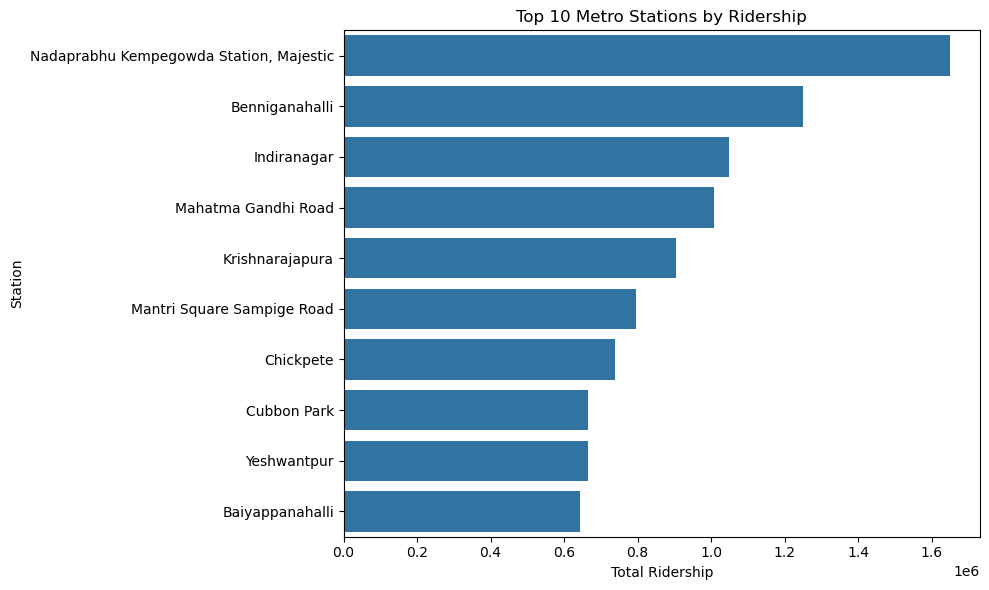

In [33]:
# Select the top 10 stations for visualization.
top_10_stations = station_ridership.head(10)

# Create the bar chart.
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_stations.values,
    y=top_10_stations.index
)

plt.title("Top 10 Metro Stations by Ridership")
plt.xlabel("Total Ridership")
plt.ylabel("Station")
plt.tight_layout()

plt.show()

### Hourly Ridership

We aggregate ridership by hour to identify the periods of highest passenger demand across the metro network.

In [34]:
# Calculate total ridership for each hour of the day.
hourly_ridership = (
    df.groupby("Hour")["Ridership"]
    .sum()
    .sort_values(ascending=False)
)

hourly_ridership

Hour
18    3330084
9     3105111
17    2870284
19    2740976
8     2633907
16    2313129
10    2273407
15    1830167
20    1823085
11    1731081
13    1719524
14    1699369
12    1660593
7     1430096
21    1159397
22     635188
6      535167
5      214570
23      85980
4       45473
0         666
3         628
1           0
2           0
Name: Ridership, dtype: int64

### Hourly Ridership Pattern

The following line chart shows how passenger demand changes across the 24 hours of the day. The chronological order helps identify peak and off-peak travel periods.

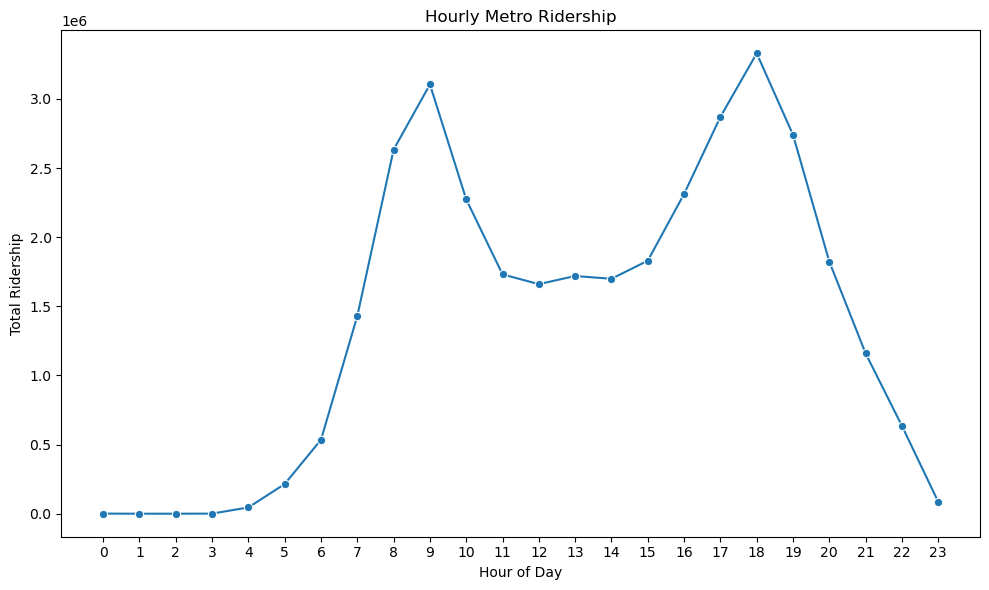

In [35]:
# Aggregate ridership by hour in chronological order.
hourly_ridership = df.groupby("Hour")["Ridership"].sum()

# Create the hourly ridership trend.
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=hourly_ridership.index,
    y=hourly_ridership.values,
    marker="o"
)

plt.title("Hourly Metro Ridership")
plt.xlabel("Hour of Day")
plt.ylabel("Total Ridership")
plt.xticks(range(24))
plt.tight_layout()

plt.show()

### Weekday vs Weekend Ridership

We compare total passenger ridership between weekdays and weekends to understand how demand changes based on the day type.

In [36]:
# Calculate total ridership for weekdays and weekends.
weekday_weekend_ridership = (
    df.groupby("Is_Weekend")["Ridership"]
    .sum()
)

weekday_weekend_ridership

Is_Weekend
False    25646867
True      8191015
Name: Ridership, dtype: int64

### Average Daily Ridership by Day Type

Because the dataset contains a different number of weekdays and weekends, we compare average daily ridership to make the comparison more meaningful.

In [37]:
# Calculate total ridership for each date.
daily_ridership_by_type = (
    df.groupby(["Date", "Is_Weekend"])["Ridership"]
    .sum()
    .reset_index()
)

# Calculate the average daily ridership for each day type.
average_ridership_by_type = (
    daily_ridership_by_type
    .groupby("Is_Weekend")["Ridership"]
    .mean()
)

# Display the results.
average_ridership_by_type

Is_Weekend
False    754319.617647
True     585072.500000
Name: Ridership, dtype: float64

### Weekday vs Weekend Ridership

The following bar chart compares average daily passenger ridership between weekdays and weekends.

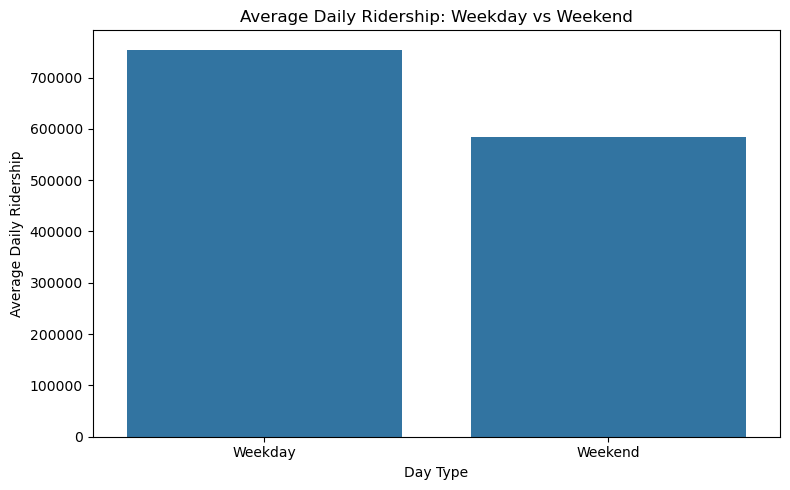

In [38]:
# Prepare labels for the two day types.
day_type_labels = {
    False: "Weekday",
    True: "Weekend"
}

# Convert the Boolean index into readable labels.
average_ridership_chart = average_ridership_by_type.rename(index=day_type_labels)

# Create the comparison chart.
plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_ridership_chart.index,
    y=average_ridership_chart.values
)

plt.title("Average Daily Ridership: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Ridership")
plt.tight_layout()

plt.show()

### Daily Ridership Trend

We examine total passenger ridership by date to identify daily variations and unusual demand patterns across the observed period.

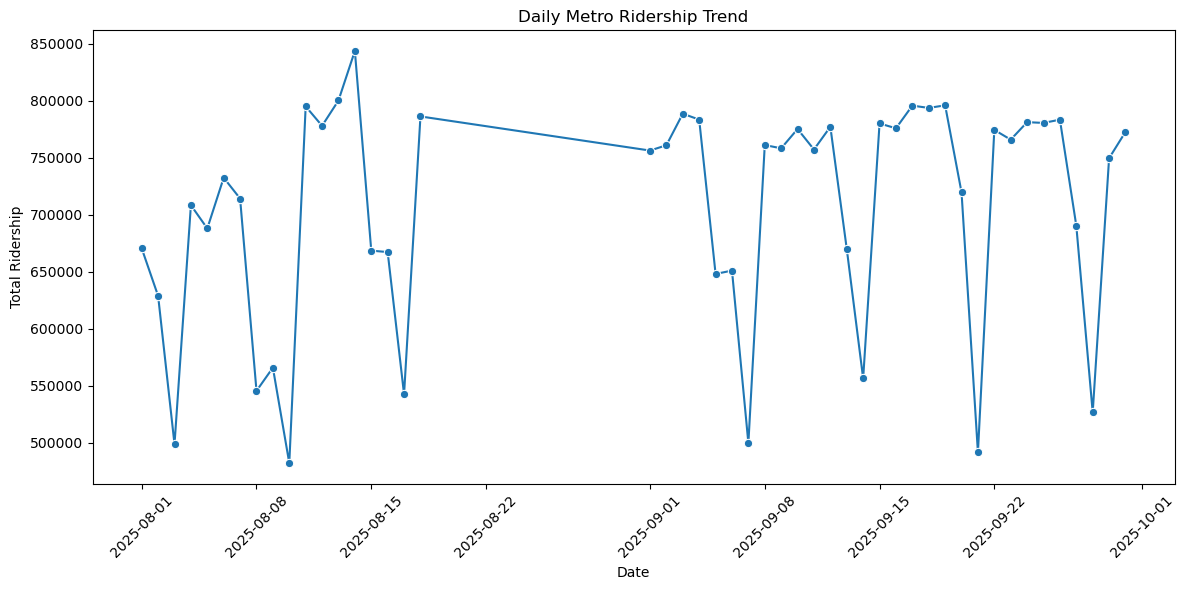

In [39]:
# Calculate total ridership for each date.
daily_ridership = (
    df.groupby("Date")["Ridership"]
    .sum()
    .sort_index()
)

# Create the daily ridership trend.
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=daily_ridership.index,
    y=daily_ridership.values,
    marker="o"
)

plt.title("Daily Metro Ridership Trend")
plt.xlabel("Date")
plt.ylabel("Total Ridership")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Highest and Lowest Ridership Days

We identify the dates with the highest and lowest total recorded ridership to understand the range of daily passenger demand.

In [40]:
# Identify the day with the highest and lowest total ridership.
highest_ridership_day = daily_ridership.idxmax()
lowest_ridership_day = daily_ridership.idxmin()

highest_ridership = daily_ridership.max()
lowest_ridership = daily_ridership.min()

print("Highest Ridership Day:", highest_ridership_day)
print("Highest Ridership:", highest_ridership)

print("Lowest Ridership Day:", lowest_ridership_day)
print("Lowest Ridership:", lowest_ridership)

Highest Ridership Day: 2025-08-14 00:00:00
Highest Ridership: 843684
Lowest Ridership Day: 2025-08-10 00:00:00
Lowest Ridership: 482205


### Day Type of Extreme Ridership Days

We examine the day of the week and day type associated with the highest and lowest ridership dates to determine whether the observed extremes align with weekday and weekend demand patterns.

In [41]:
# Retrieve the day information for the highest and lowest ridership dates.
extreme_days = df[
    df["Date"].isin([highest_ridership_day, lowest_ridership_day])
][["Date", "Day_Name", "Is_Weekend"]].drop_duplicates()

extreme_days.sort_values("Date")

,Date,Day_Name,Is_Weekend
14928,2025-08-10,Sunday,True
22560,2025-08-14,Thursday,False


### Average Daily Ridership by Station

To account for differences in station-date coverage, we calculate the average daily ridership for each station. This provides a more comparable measure of typical passenger demand across stations.

In [42]:
# Calculate total ridership for each station on each observed date.
station_daily_ridership = (
    df.groupby(["Station", "Date"])["Ridership"]
    .sum()
    .reset_index()
)

# Calculate the average daily ridership for each station.
average_station_ridership = (
    station_daily_ridership
    .groupby("Station")["Ridership"]
    .mean()
    .sort_values(ascending=False)
)

average_station_ridership.head(10)

Station
Nadaprabhu Kempegowda Station, Majestic    34365.208333
Benniganahalli                             26055.333333
Indiranagar                                21852.833333
Mahatma Gandhi Road                        20982.833333
Krishnarajapura                            18843.916667
Mantri Square Sampige Road                 16594.166667
Chickpete                                  15372.000000
Cubbon Park                                13879.937500
Yeshwantpur                                13878.937500
Baiyappanahalli                            13429.666667
Name: Ridership, dtype: float64

### Top 10 Stations by Average Daily Ridership

The following visualization compares the average daily ridership of the ten highest-demand stations, providing a more comparable measure of typical station activity.

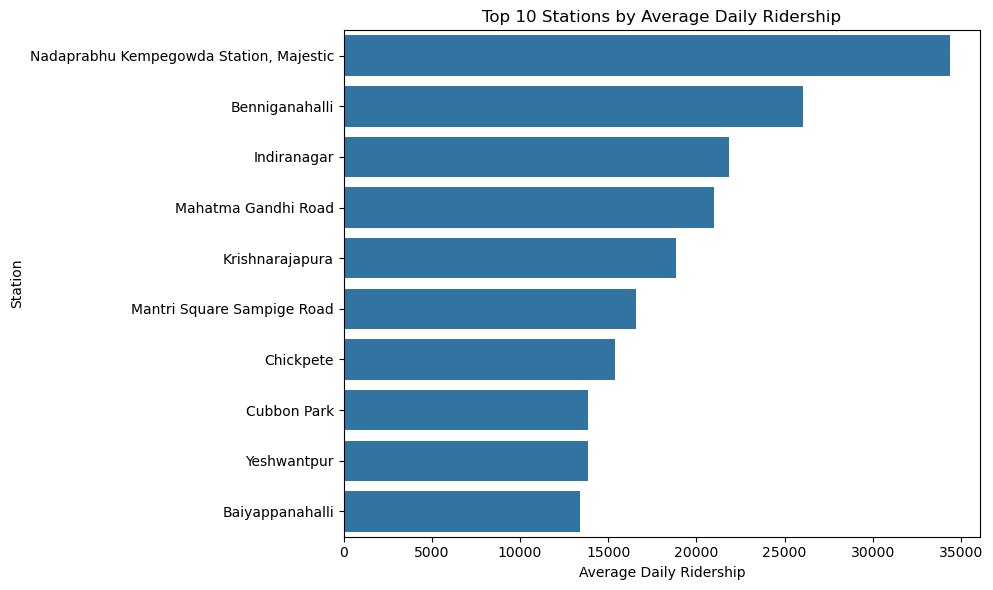

In [43]:
# Select the top 10 stations by average daily ridership.
top_10_average_stations = average_station_ridership.head(10)

# Create the bar chart.
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_average_stations.values,
    y=top_10_average_stations.index
)

plt.title("Top 10 Stations by Average Daily Ridership")
plt.xlabel("Average Daily Ridership")
plt.ylabel("Station")
plt.tight_layout()

plt.show()

### Ridership by Day of Week

We aggregate ridership by day of the week to identify recurring patterns in passenger demand across the weekly cycle.

In [44]:
# Calculate average daily ridership for each day of the week.
daily_day_type = (
    df.groupby(["Date", "Day_Name"])["Ridership"]
    .sum()
    .reset_index()
)

day_of_week_ridership = (
    daily_day_type
    .groupby("Day_Name")["Ridership"]
    .mean()
)

# Arrange the days in their natural weekly order.
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_of_week_ridership = day_of_week_ridership.reindex(day_order)

day_of_week_ridership

Day_Name
Monday       763921.375000
Tuesday      757102.571429
Wednesday    778927.500000
Thursday     778815.166667
Friday       698474.571429
Saturday     656177.142857
Sunday       513967.857143
Name: Ridership, dtype: float64

### Average Daily Ridership by Day of Week

The following visualization compares typical daily passenger demand across the seven days of the week.

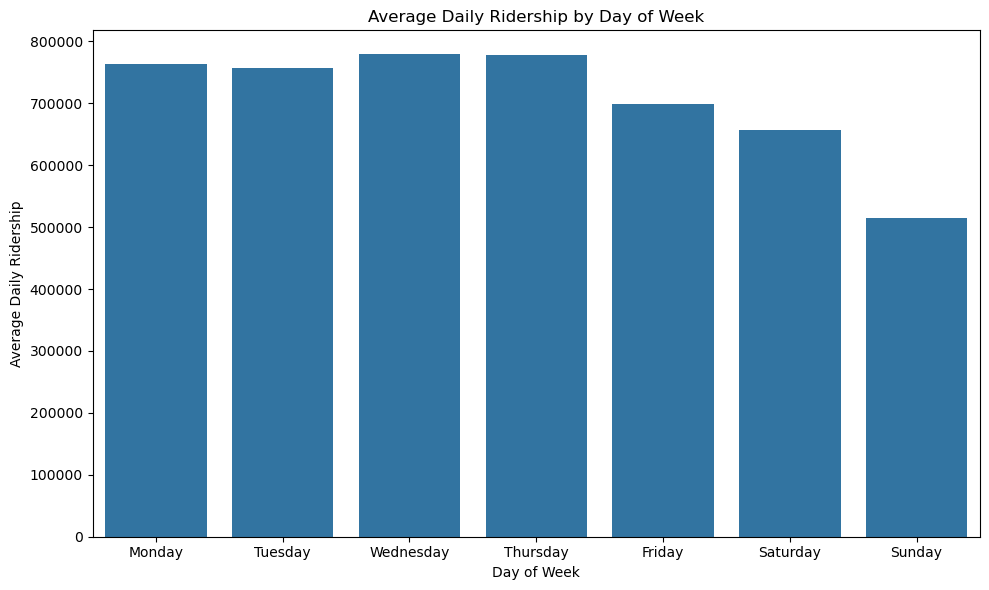

In [45]:
# Create the day-of-week ridership chart.
plt.figure(figsize=(10, 6))

sns.barplot(
    x=day_of_week_ridership.index,
    y=day_of_week_ridership.values
)

plt.title("Average Daily Ridership by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Ridership")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Station-Level Hourly Demand

A heatmap is used to examine how passenger demand varies across different hours at the highest-demand stations. This helps identify station-specific peak periods rather than relying only on network-wide trends.

In [46]:
# Select the top 15 stations based on average daily ridership.
top_15_stations = average_station_ridership.head(15).index

# Filter the dataset to include only the selected stations.
top_station_data = df[df["Station"].isin(top_15_stations)]

# Calculate average ridership for each station and hour.
station_hour_ridership = (
    top_station_data
    .groupby(["Station", "Hour"])["Ridership"]
    .mean()
    .unstack()
)

# Reorder stations from highest to lowest average daily ridership.
station_hour_ridership = station_hour_ridership.loc[
    top_15_stations
]

station_hour_ridership

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Station,,,,,,,,,,,,,,,,,,,,,
"Nadaprabhu Kempegowda Station, Majestic",0.000000,0.0,0.0,8.875000,267.395833,760.375000,1262.770833,1750.229167,2069.395833,2323.770833,...,1864.270833,1738.958333,2024.666667,2419.750000,2616.708333,2564.583333,2151.000000,1655.520833,1032.104167,244.479167
Benniganahalli,0.750000,0.0,0.0,0.000000,48.083333,186.437500,489.895833,1361.083333,2594.291667,3224.666667,...,1102.916667,1078.500000,1322.875000,1611.812500,1807.895833,1651.333333,1181.270833,762.354167,405.083333,53.208333
Indiranagar,0.041667,0.0,0.0,0.000000,6.541667,48.041667,179.500000,583.770833,1137.895833,1598.583333,...,979.562500,1197.479167,1604.833333,2129.604167,2958.437500,2496.437500,1516.625000,930.145833,553.250000,98.208333
Mahatma Gandhi Road,0.000000,0.0,0.0,0.000000,2.041667,15.770833,58.666667,145.416667,308.333333,375.791667,...,1058.270833,1382.625000,1664.562500,2338.895833,3323.895833,2969.104167,2006.625000,1368.250000,1031.104167,272.125000
Krishnarajapura,0.729167,0.0,0.0,0.333333,34.645833,157.312500,370.833333,930.104167,1718.562500,2257.208333,...,733.729167,881.479167,1206.187500,1358.583333,1331.395833,1203.645833,878.333333,666.187500,309.312500,37.875000
Mantri Square Sampige Road,0.000000,0.0,0.0,0.020833,2.375000,32.354167,111.062500,399.416667,796.979167,1014.333333,...,1030.375000,1021.854167,1230.416667,1587.958333,1816.500000,1739.312500,1240.541667,885.875000,523.291667,52.270833
Chickpete,0.000000,0.0,0.0,0.000000,0.541667,12.833333,54.645833,186.479167,326.625000,390.250000,...,1402.312500,1537.333333,1581.125000,1691.687500,1696.041667,1624.166667,1413.708333,672.604167,143.208333,15.062500
Cubbon Park,0.000000,0.0,0.0,0.000000,2.583333,15.041667,65.604167,203.083333,396.041667,439.500000,...,714.104167,855.187500,1150.250000,2006.520833,2749.583333,1741.666667,836.187500,428.250000,234.437500,37.062500
Yeshwantpur,0.000000,0.0,0.0,2.625000,254.270833,587.062500,663.062500,1265.416667,1252.645833,1011.541667,...,543.791667,436.562500,408.625000,715.604167,743.166667,809.020833,1290.354167,583.229167,292.104167,77.604167


### Station-Level Hourly Demand Heatmap

The heatmap visualizes average hourly ridership across the top 15 stations. Darker cells represent higher passenger demand, making station-specific peak periods easier to identify.

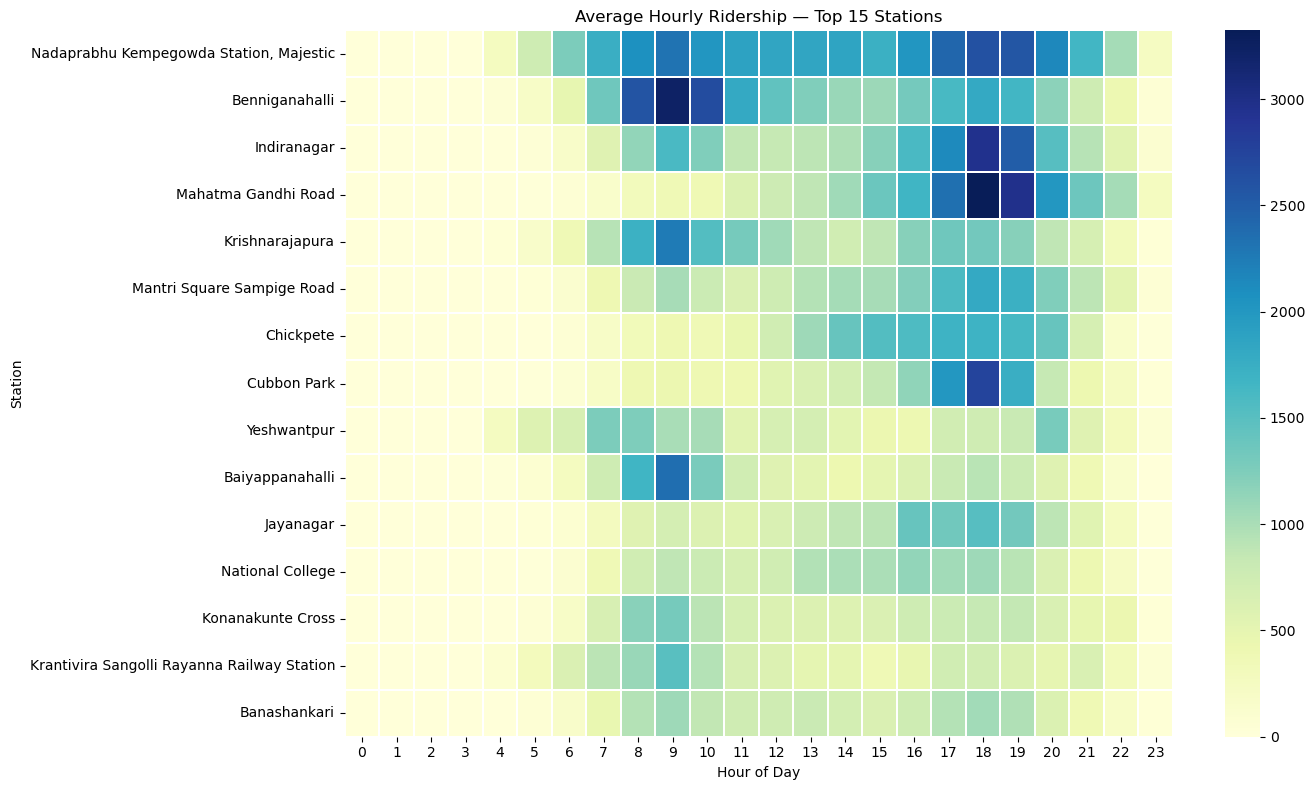

In [47]:
# Create the station-hour heatmap.
plt.figure(figsize=(14, 8))

sns.heatmap(
    station_hour_ridership,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Average Hourly Ridership — Top 15 Stations")
plt.xlabel("Hour of Day")
plt.ylabel("Station")
plt.tight_layout()

plt.show()

### Ridership by Time Period

We aggregate ridership across predefined time periods to compare passenger demand between overnight, peak, midday, and late-evening travel periods.

In [48]:
# Calculate total ridership for each time period.
time_period_ridership = (
    df.groupby("Time_Period")["Ridership"]
    .sum()
)

# Arrange the periods in chronological order.
time_period_order = [
    "Night",
    "Morning Peak",
    "Midday",
    "Evening Peak",
    "Late Evening"
]

time_period_ridership = time_period_ridership.reindex(time_period_order)

time_period_ridership

Time_Period
Night             261337
Morning Peak     7704281
Midday          10914141
Evening Peak    11254473
Late Evening     3703650
Name: Ridership, dtype: int64

### Total Ridership by Time Period

The following visualization compares total passenger ridership across the defined time periods.

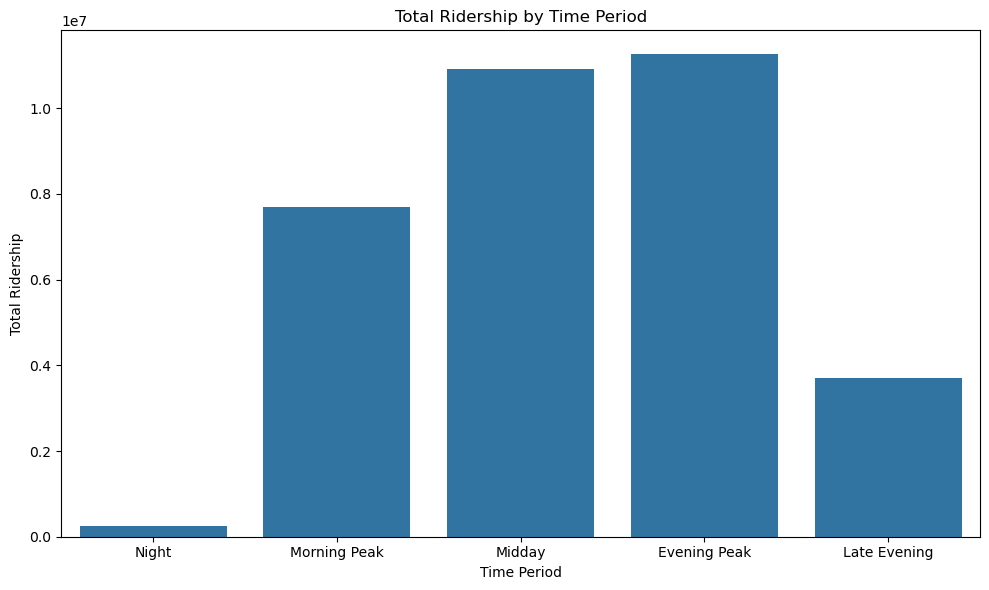

In [49]:
# Create the time-period ridership chart.
plt.figure(figsize=(10, 6))

sns.barplot(
    x=time_period_ridership.index,
    y=time_period_ridership.values
)

plt.title("Total Ridership by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Total Ridership")
plt.tight_layout()

plt.show()

### Top Station by Time Period

We identify the station with the highest total ridership within each time period to understand where passenger demand is concentrated throughout the day.

In [50]:
# Calculate total ridership by station and time period.
station_time_period_ridership = (
    df.groupby(["Time_Period", "Station"])["Ridership"]
    .sum()
    .reset_index()
)

# Find the highest-ridership station within each time period.
top_station_by_period = (
    station_time_period_ridership
    .loc[
        station_time_period_ridership
        .groupby("Time_Period")["Ridership"]
        .idxmax()
    ]
    .sort_values("Time_Period")
)

top_station_by_period

,Time_Period,Station,Ridership
48,Evening Peak,Mahatma Gandhi Road,494230
135,Late Evening,"Nadaprabhu Kempegowda Station, Majestic",243989
218,Midday,"Nadaprabhu Kempegowda Station, Majestic",538252
253,Morning Peak,Benniganahalli,368157
384,Night,"Nadaprabhu Kempegowda Station, Majestic",49759


### Busiest Station Across Time Periods

The following visualization shows the highest-ridership station within each time period, highlighting how passenger demand shifts across the network throughout the day.

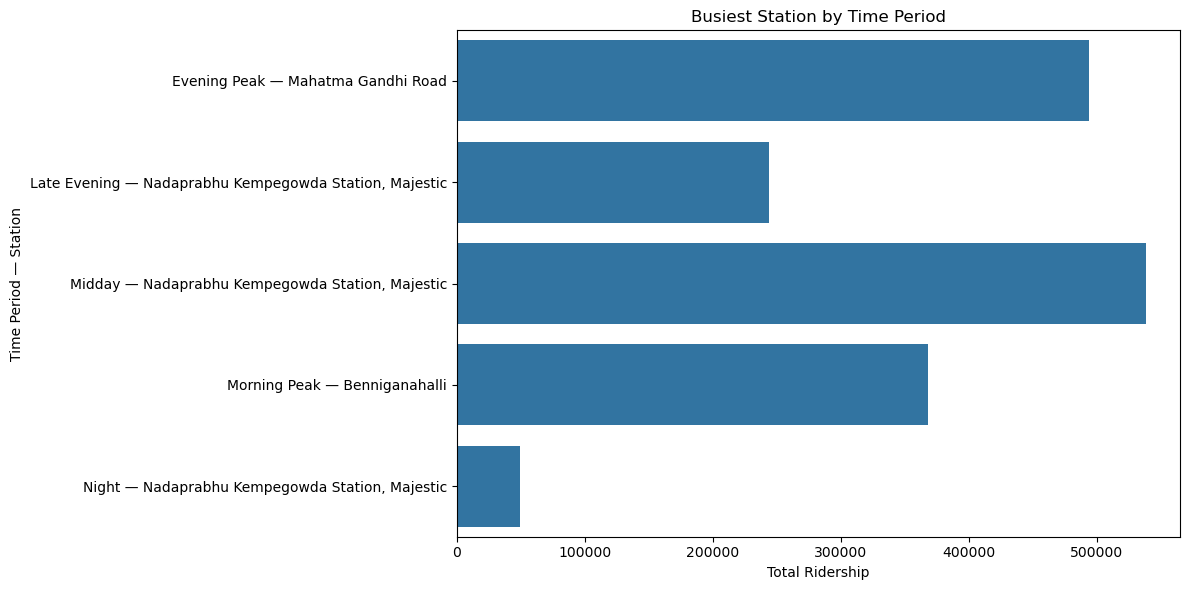

In [51]:
# Create a readable label for each time period and its busiest station.
top_station_by_period["Period_Station"] = (
    top_station_by_period["Time_Period"]
    + " — "
    + top_station_by_period["Station"]
)

# Create the comparison chart.
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_station_by_period["Ridership"],
    y=top_station_by_period["Period_Station"]
)

plt.title("Busiest Station by Time Period")
plt.xlabel("Total Ridership")
plt.ylabel("Time Period — Station")
plt.tight_layout()

plt.show()

### Peak Hour by Major Station

We identify the busiest hour for each of the top 15 stations to understand how passenger demand varies across locations.

In [52]:
# Calculate average ridership for each station and hour.
station_hour_average = (
    df[df["Station"].isin(top_15_stations)]
    .groupby(["Station", "Hour"])["Ridership"]
    .mean()
    .reset_index()
)

# Find the busiest hour for each station.
peak_hour_by_station = (
    station_hour_average
    .loc[
        station_hour_average
        .groupby("Station")["Ridership"]
        .idxmax()
    ]
    .sort_values("Ridership", ascending=False)
)

peak_hour_by_station

,Station,Hour,Ridership
258,Mahatma Gandhi Road,18,3323.895833
57,Benniganahalli,9,3224.666667
138,Indiranagar,18,2958.437500
114,Cubbon Park,18,2749.583333
306,"Nadaprabhu Kempegowda Station, Majestic",18,2616.708333
9,Baiyappanahalli,9,2359.833333
225,Krishnarajapura,9,2257.208333
282,Mantri Square Sampige Road,18,1816.500000
90,Chickpete,18,1696.041667
162,Jayanagar,18,1515.958333


### Peak Hour at Major Stations

The following visualization shows the peak hour and corresponding average ridership for each of the top 15 stations.

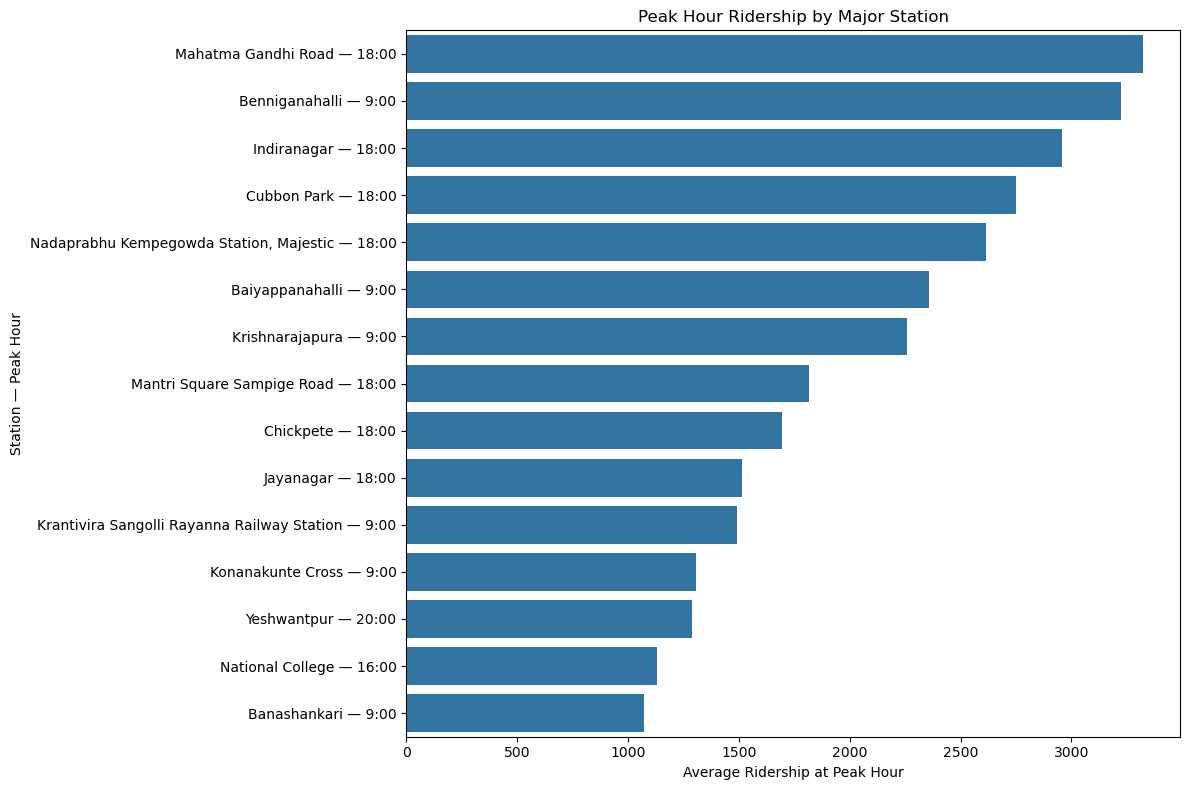

In [53]:
# Create a readable label showing the station and its peak hour.
peak_hour_by_station["Station_Hour"] = (
    peak_hour_by_station["Station"]
    + " — "
    + peak_hour_by_station["Hour"].astype(str)
    + ":00"
)

# Create the visualization.
plt.figure(figsize=(12, 8))

sns.barplot(
    x=peak_hour_by_station["Ridership"],
    y=peak_hour_by_station["Station_Hour"]
)

plt.title("Peak Hour Ridership by Major Station")
plt.xlabel("Average Ridership at Peak Hour")
plt.ylabel("Station — Peak Hour")
plt.tight_layout()

plt.show()

### Station Ridership Contribution

We calculate the share of total network ridership contributed by the highest-demand stations to understand how passenger demand is distributed across the metro network.

In [54]:
# Calculate the total ridership contributed by the top 5 stations.
top_5_ridership = station_ridership.head(5).sum()

# Calculate the total ridership contributed by the top 10 stations.
top_10_ridership = station_ridership.head(10).sum()

# Calculate their percentage contribution to total network ridership.
top_5_share = (top_5_ridership / total_ridership) * 100
top_10_share = (top_10_ridership / total_ridership) * 100

print("Top 5 Stations Share:", round(top_5_share, 2), "%")
print("Top 10 Stations Share:", round(top_10_share, 2), "%")

Top 5 Stations Share: 17.32 %
Top 10 Stations Share: 27.7 %


### Lowest-Demand Stations

We identify stations with the lowest average daily ridership to understand the distribution of passenger demand across the network and highlight stations with relatively lower typical activity.

In [55]:
# Display the 10 stations with the lowest average daily ridership.
average_station_ridership.tail(10).sort_values()

Station
Beratena Agrahara                750.473684
Manjunathanagara                1224.041667
Singasandra                     1468.210526
Biocon Hebbagodi                1635.763158
Ragigudda                       2231.476190
Peenya Industry                 2254.666667
Pantharapalya - Nayandahalli    2258.604167
Huskur Road                     2263.820513
Hopefarm Channasandra           2613.833333
Thalaghattapura                 2867.125000
Name: Ridership, dtype: float64

# Key Findings from Python EDA

The exploratory analysis identified several important passenger-demand patterns across the Bengaluru Metro network.

- Total recorded ridership was 33,837,882 passengers across the observed dataset.
- Average daily recorded ridership was approximately 704,956 passengers.
- Nadaprabhu Kempegowda Station, Majestic recorded the highest total and average daily ridership among the stations analyzed.
- 18:00 was the highest-ridership hour across the network, followed by 09:00.
- Average weekday ridership was approximately 29% higher than average weekend ridership.
- Wednesday recorded the highest average daily ridership among the seven days of the week, while Sunday recorded the lowest.
- Evening Peak recorded the highest total ridership among the defined time periods.
- Major stations showed different peak-hour patterns, with many stations peaking at either 09:00 or 18:00.
- The top 5 stations contributed 17.32% of total recorded ridership, while the top 10 contributed 27.70%.
- Ridership was distributed across the network rather than being concentrated entirely in a small number of stations.

## Data Quality Considerations

The dataset does not contain complete station-level observations for every date in the observed period. Therefore, station-level comparisons are interpreted using the available recorded observations, and conclusions are not treated as estimates of missing station activity.

## Loading Data into MySQL

The cleaned station-level ridership data is loaded into MySQL in batches for efficient database insertion.

In [57]:
import mysql.connector

In [58]:
# Connect to the MySQL project database.
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sql@2026",
    database="metro_operations"
)

print("Connected to MySQL successfully.")

Connected to MySQL successfully.


In [59]:
# Create a cursor for executing SQL commands.
cursor = connection.cursor()

# SQL statement for inserting the four original CSV columns.
insert_query = """
INSERT INTO station_hourly
(Date, Hour, Station, Ridership)
VALUES (%s, %s, %s, %s)
"""

print("MySQL insert query prepared.")

MySQL insert query prepared.


In [61]:
# Read the CSV file.
csv_path = "../data/station-hourly.csv"

data_to_import = pd.read_csv(
    csv_path,
    sep=";"
)

print("Rows to import:", len(data_to_import))

Rows to import: 92280


In [62]:
# Convert the DataFrame into tuples for MySQL insertion.
rows_to_insert = list(
    data_to_import[
        ["Date", "Hour", "Station", "Ridership"]
    ].itertuples(index=False, name=None)
)

# Insert the data in batches of 1,000 rows.
batch_size = 1000

for start in range(0, len(rows_to_insert), batch_size):
    batch = rows_to_insert[start:start + batch_size]
    
    cursor.executemany(insert_query, batch)
    connection.commit()
    
    print(
        f"Imported {min(start + batch_size, len(rows_to_insert))} "
        f"of {len(rows_to_insert)} rows"
    )

print("Data import completed successfully.")

Imported 1000 of 92280 rows
Imported 2000 of 92280 rows
Imported 3000 of 92280 rows
Imported 4000 of 92280 rows
Imported 5000 of 92280 rows
Imported 6000 of 92280 rows
Imported 7000 of 92280 rows
Imported 8000 of 92280 rows
Imported 9000 of 92280 rows
Imported 10000 of 92280 rows
Imported 11000 of 92280 rows
Imported 12000 of 92280 rows
Imported 13000 of 92280 rows
Imported 14000 of 92280 rows
Imported 15000 of 92280 rows
Imported 16000 of 92280 rows
Imported 17000 of 92280 rows
Imported 18000 of 92280 rows
Imported 19000 of 92280 rows
Imported 20000 of 92280 rows
Imported 21000 of 92280 rows
Imported 22000 of 92280 rows
Imported 23000 of 92280 rows
Imported 24000 of 92280 rows
Imported 25000 of 92280 rows
Imported 26000 of 92280 rows
Imported 27000 of 92280 rows
Imported 28000 of 92280 rows
Imported 29000 of 92280 rows
Imported 30000 of 92280 rows
Imported 31000 of 92280 rows
Imported 32000 of 92280 rows
Imported 33000 of 92280 rows
Imported 34000 of 92280 rows
Imported 35000 of 92280

In [63]:
cursor.execute("TRUNCATE TABLE station_hourly")
connection.commit()

# Convert the DataFrame into tuples for MySQL insertion.
rows_to_insert = list(
    data_to_import[
        ["Date", "Hour", "Station", "Ridership"]
    ].itertuples(index=False, name=None)
)

# Insert the data in batches.
batch_size = 1000

for start in range(0, len(rows_to_insert), batch_size):
    batch = rows_to_insert[start:start + batch_size]

    cursor.executemany(insert_query, batch)
    connection.commit()

print(f"Successfully imported {len(rows_to_insert)} rows.")

Successfully imported 92280 rows.
